In [1]:
# Install required packages
!pip install opencv-python-headless albumentations -q

In [2]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from src.utils.constants import *
from src.preprocessing.transforms import *
from src.preprocessing.preprocess_pipelines import *
from src.preprocessing.visualize import *
from src.preprocessing.batch_process import *
from src.analysis.compare import *

✓ IM2LATEX preprocessing pipeline ready
✓ CROHME preprocessing pipeline ready
✓ Batch processing function ready

Note: Saving all preprocessed images will require significant disk space.
Consider processing on-the-fly during training instead.


---

## Configuration & Constants

Based on EDA findings, we define the canonical format.

In [4]:
print(f"Target format: [{NUM_CHANNELS}, {TARGET_HEIGHT}, {TARGET_WIDTH}]")
print(f"\nOutput paths:")
print(f"  IM2LATEX: {IM2LATEX_OUTPUT_PATH}")
print(f"  CROHME: {CROHME_OUTPUT_PATH}")

Target format: [1, 128, 768]

Output paths:
  IM2LATEX: /app/data/preprocessed/im2latex
  CROHME: /app/data/preprocessed/crohme


---

## IM2LATEX Preprocessing Pipeline

**Strategy**: Keep images sharp and clean, minimal processing.

### Pipeline Steps:
1. Convert to grayscale
2. Resize to fixed height (128) keeping aspect ratio
3. Pad to fixed width (768)
4. Light normalization (using dataset statistics)
5. Optional: Very light blur (low probability)

---

## CROHME Preprocessing Pipeline

**Strategy**: Remove whitespace, enhance contrast, aggressive augmentation.

### Pipeline Steps:
1. Convert to grayscale
2. **Crop content** (remove excess whitespace)
3. Resize to fixed height (128) keeping aspect ratio
4. Pad to fixed width (768)
5. **Per-image normalization** (important!)
6. **Contrast enhancement**
7. Augmentation: brightness, contrast, thickness variation

---

## Visualization: Compare Original vs Preprocessed

Let's verify the preprocessing pipelines visually.

In [5]:
# Load sample datasets
im2latex_train = pd.read_csv(IM2LATEX_LABEL_PATH / "im2latex_train.csv")
crohme_df = pd.read_csv(CROHME_CSV_PATH)

print(f"IM2LATEX samples: {len(im2latex_train):,}")
print(f"CROHME samples: {len(crohme_df):,}")

IM2LATEX samples: 75,275
CROHME samples: 18,855


=== IM2LATEX Preprocessing ===


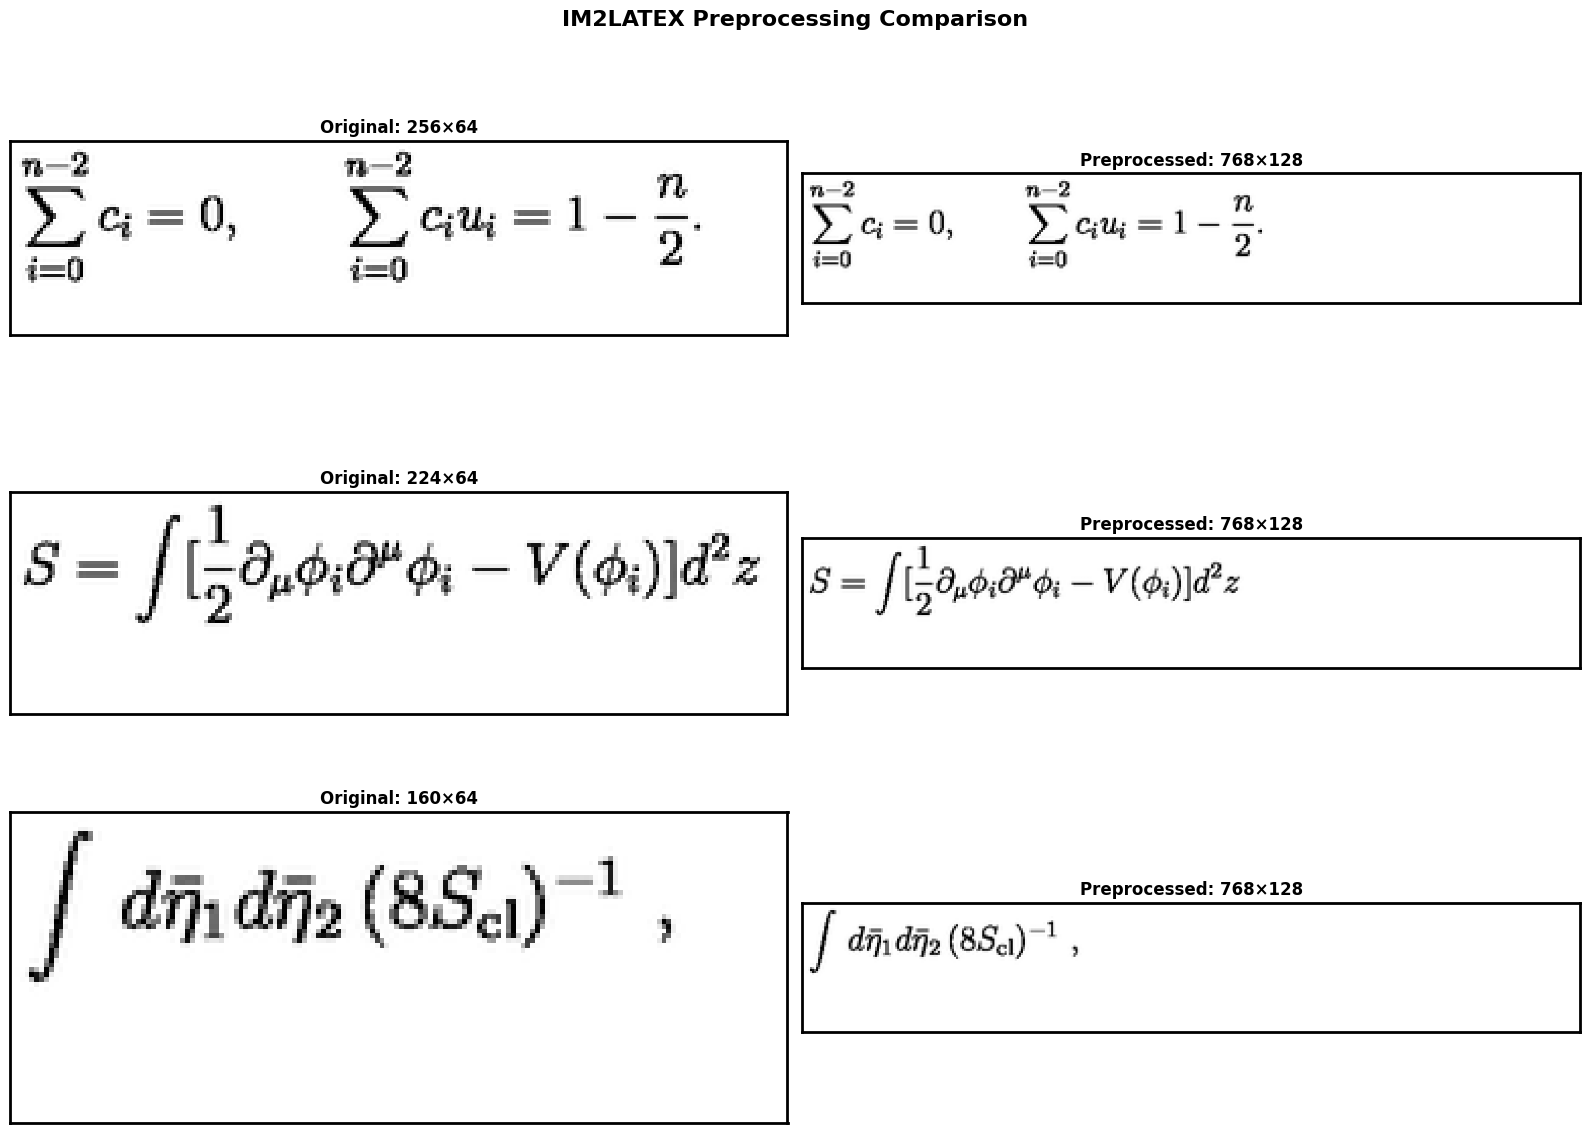

In [6]:
# Visualize IM2LATEX
print("=== IM2LATEX Preprocessing ===")
visualize_preprocessing(im2latex_train, preprocess_im2latex, 'im2latex', num_samples=3)

=== CROHME Preprocessing ===


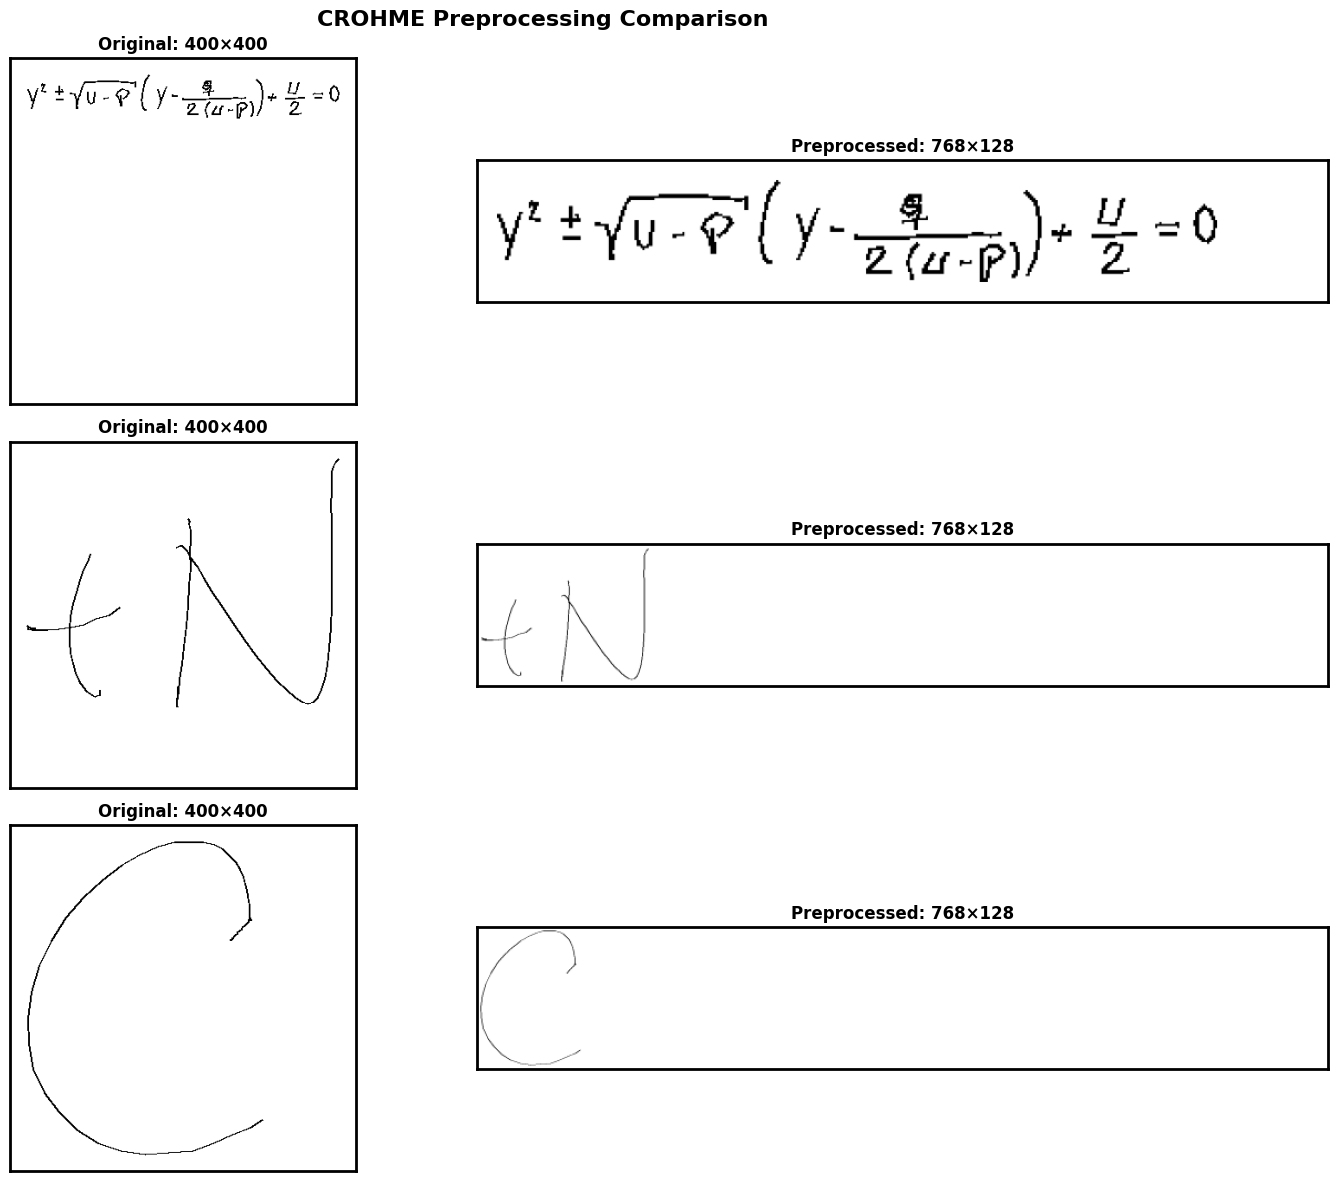

In [7]:
# Visualize CROHME
print("=== CROHME Preprocessing ===")
visualize_preprocessing(crohme_df, preprocess_crohme, 'crohme', num_samples=3)

### Check CROHME Cropping Effectiveness

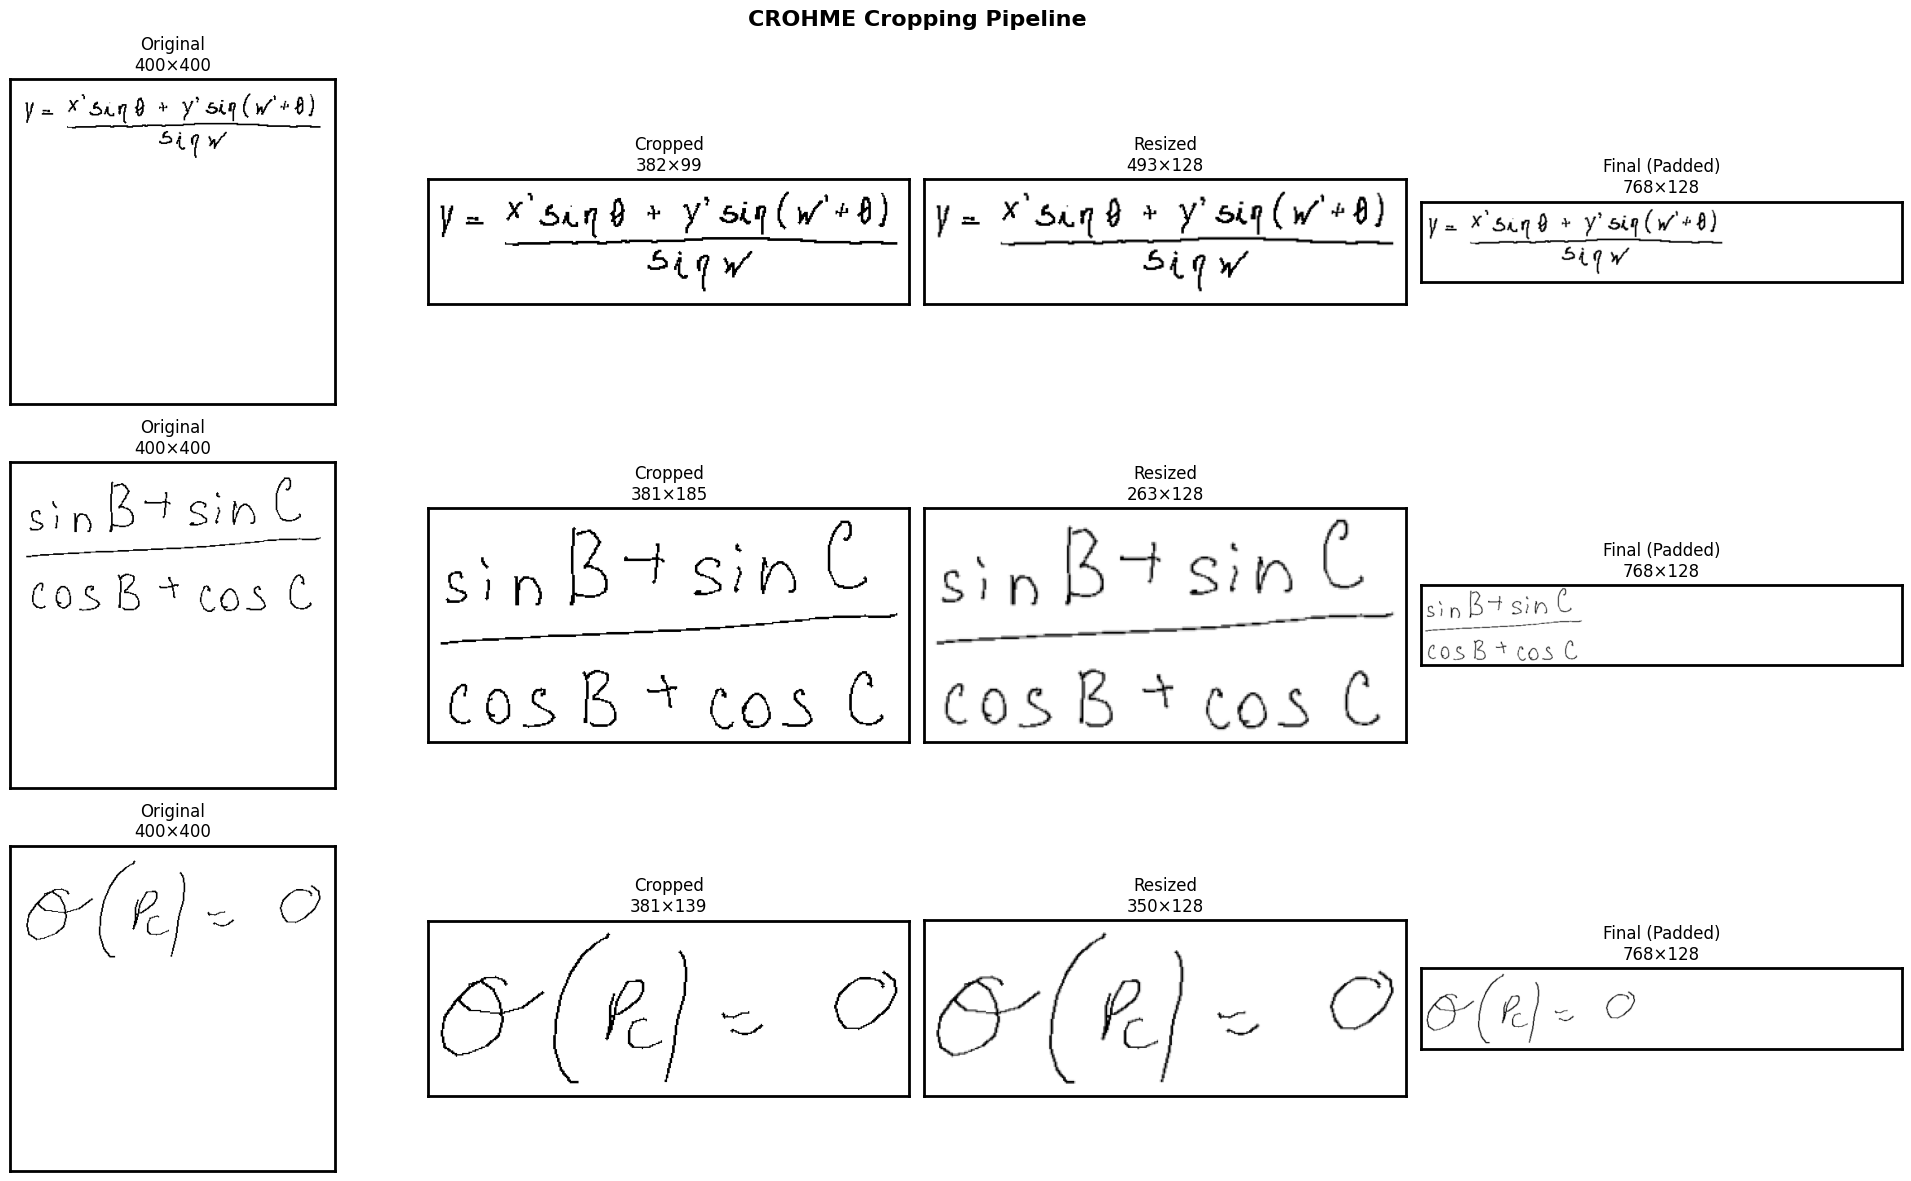

In [8]:
visualize_crohme_cropping(crohme_df, num_samples=3)

---

## Augmentation Visualization

Compare preprocessing with and without augmentation.

=== IM2LATEX Augmentation (Minimal) ===


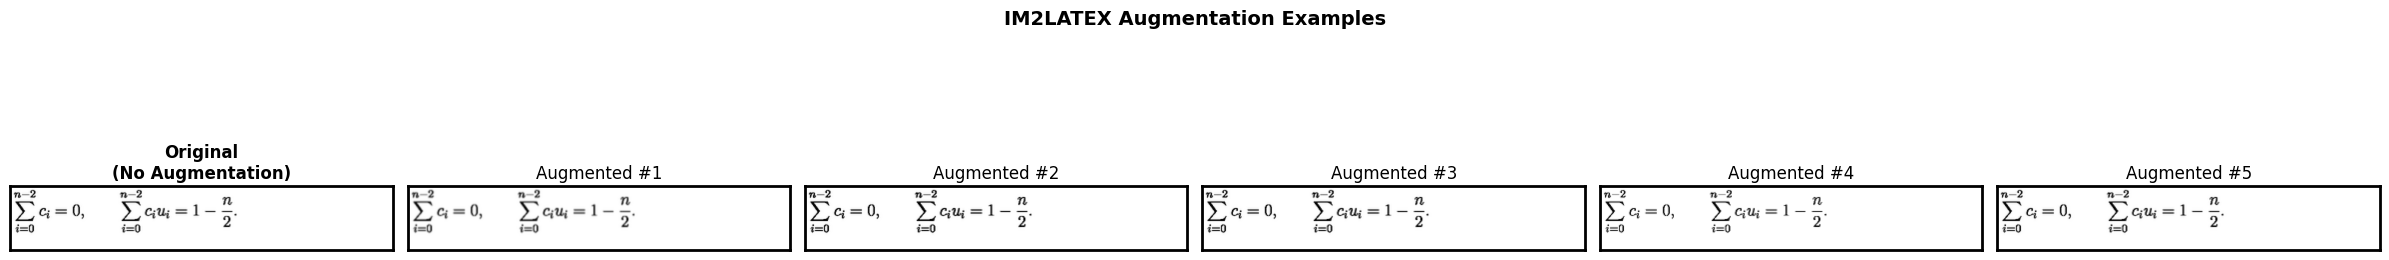

In [9]:
print("=== IM2LATEX Augmentation (Minimal) ===")
visualize_augmentation(im2latex_train, preprocess_im2latex, 'im2latex', 5)

=== CROHME Augmentation (Aggressive) ===


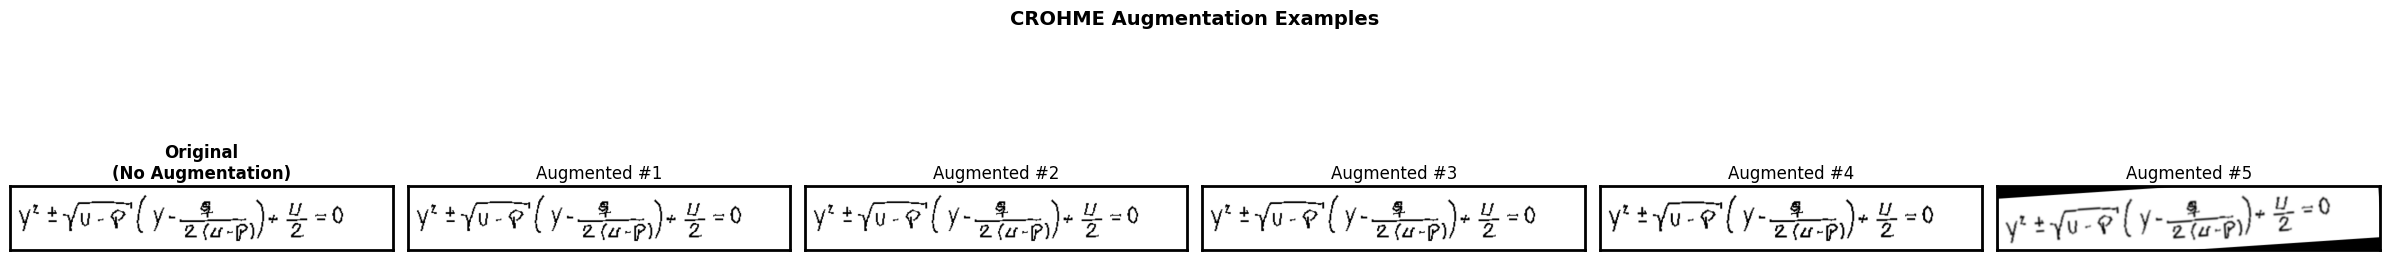

In [10]:
print("=== CROHME Augmentation (Aggressive) ===")
visualize_augmentation(crohme_df, preprocess_crohme,'crohme', 5)

---

## Statistics Analysis: Before vs After

Compare image statistics before and after preprocessing.

Analyzing im2latex: 100%|██████████| 500/500 [00:05<00:00, 97.93it/s] 



IM2LATEX Statistics (n=500)
Metric               Original             Preprocessed        
------------------------------------------------------------
Mean (avg)           0.9438               244.8591            
Mean (std)           0.0161               4.4007              
Std (avg)            0.1907               40.3387             
Std (std)            0.0248               8.2114              



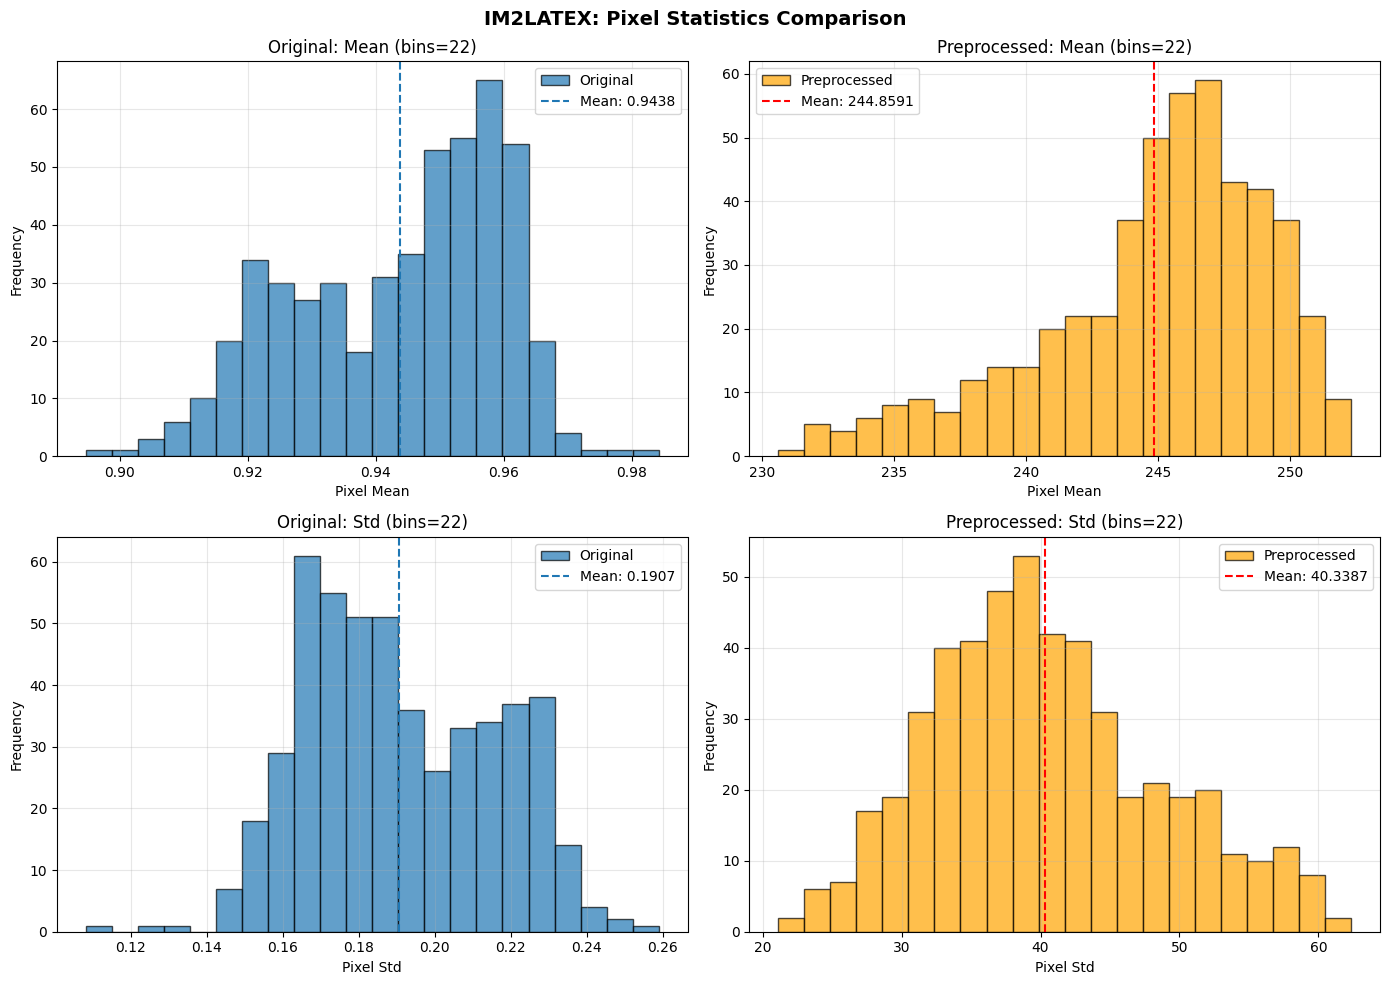

In [11]:
analyze_preprocessing_statistics(im2latex_train, preprocess_im2latex,'im2latex', sample_size=500)

Analyzing crohme: 100%|██████████| 500/500 [00:16<00:00, 30.96it/s]



CROHME Statistics (n=500)
Metric               Original             Preprocessed        
------------------------------------------------------------
Mean (avg)           0.9889               250.1706            
Mean (std)           0.0041               4.2203              
Std (avg)            0.1032               27.7008             
Std (std)            0.0187               14.5320             



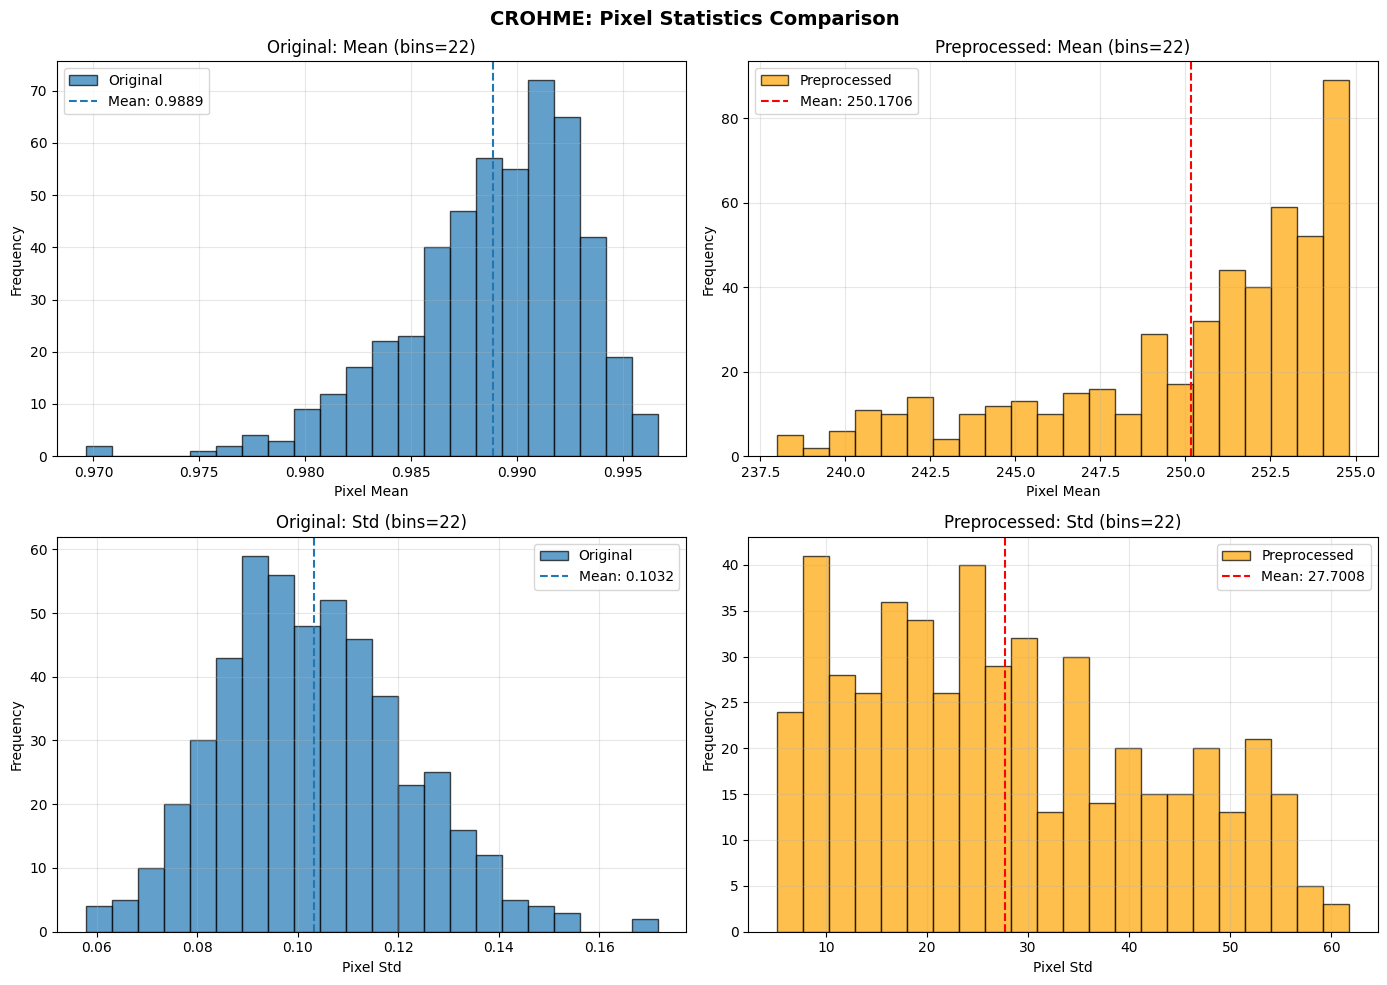

In [12]:
analyze_preprocessing_statistics(crohme_df, preprocess_crohme, 'crohme', sample_size=500)

---

## Batch Processing & Save Preprocessed Images

Process all images and save to disk for training.

In [13]:
# Process IM2LATEX (this will take time!)
# Set save_images=True to only create CSV files and .npy files without saving images.
# Images will be preprocessed on-the-fly during training

print("Processing IM2LATEX dataset...")
im2latex_splits = batch_preprocess_and_save('im2latex')

Processing IM2LATEX dataset...

Processing IM2LATEX - TRAIN split


Processing train: 100%|██████████| 75275/75275 [1:00:06<00:00, 20.87it/s]


✓ Processed 75275 / 75275 images
✓ Saved to: /app/data/preprocessed/im2latex/train.csv

Processing IM2LATEX - VAL split


Processing val: 100%|██████████| 8370/8370 [06:42<00:00, 20.81it/s]


✓ Processed 8370 / 8370 images
✓ Saved to: /app/data/preprocessed/im2latex/val.csv

Processing IM2LATEX - TEST split


Processing test: 100%|██████████| 10355/10355 [08:19<00:00, 20.75it/s]


✓ Processed 10355 / 10355 images
✓ Saved to: /app/data/preprocessed/im2latex/test.csv


In [14]:
# Process CROHME
print("Processing CROHME dataset...")
crohme_splits = batch_preprocess_and_save('crohme')

Processing CROHME dataset...

Processing CROHME - TRAIN split


Processing train: 100%|██████████| 15084/15084 [12:41<00:00, 19.80it/s]


✓ Processed 15084 / 15084 images
✓ Saved to: /app/data/preprocessed/crohme/train.csv

Processing CROHME - VAL split


Processing val: 100%|██████████| 1885/1885 [01:24<00:00, 22.28it/s]


✓ Processed 1885 / 1885 images
✓ Saved to: /app/data/preprocessed/crohme/val.csv

Processing CROHME - TEST split


Processing test: 100%|██████████| 1886/1886 [01:22<00:00, 22.83it/s]

✓ Processed 1886 / 1886 images
✓ Saved to: /app/data/preprocessed/crohme/test.csv


---

## Summary & Validation

Final checks and statistics.

In [15]:
# Summary statistics
summarize(im2latex_splits, crohme_splits)

PREPROCESSING SUMMARY

📊 IM2LATEX Dataset:
  Train:      75,275 samples
  Validation:  8,370 samples
  Test:       10,355 samples
  Total:      94,000 samples

📊 CROHME Dataset:
  Train:      15,084 samples
  Validation:  1,885 samples
  Test:        1,886 samples
  Total:      18,855 samples

🎯 Canonical Format:
  Shape:      [1, 128, 768]
  Channels:   Grayscale (1 channel)
  Height:     Fixed at 128 pixels
  Width:      Padded to 768 pixels

✅ Preprocessing Strategy:
  IM2LATEX:   Minimal processing, preserve sharpness
  CROHME:     Content cropping + contrast enhancement

📁 Output Files:
  IM2LATEX:   /app/data/preprocessed/im2latex
  CROHME:     /app/data/preprocessed/crohme


---

## Key Findings & Next Steps

1. **Unified Format**: Both datasets now follow canonical `[1, 128, 768]` format
2. **Fixed CROHME Issues**: 
   - Content cropping removes excess whitespace
   - Aspect ratio is now preserved (not forced to square)
   - Contrast enhancement addresses low std problem
3. **Domain-Specific Processing**:
   - IM2LATEX: Minimal processing, preserves print quality
   - CROHME: Aggressive preprocessing for handwriting

### 📋 Next Steps:

1. **Implement Dataset Classes** (`src/datasets/`):
   - `IM2LATEXDataset`: Load and preprocess on-the-fly
   - `CROHMEDataset`: Load and preprocess on-the-fly
   - Include augmentation for training split

2. **Tokenizer & Vocabulary** (from EDA recommendations):
   - Build unified vocabulary from IM2LATEX base
   - Add special tokens: `<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`
   - Handle CROHME label cleaning

3. **Model Architecture**:
   - Encoder: CNN (ResNet/EfficientNet) for `[1, 128, 768]` input
   - Decoder: Transformer/LSTM with attention
   - Position embeddings for max_seq_len=150

4. **Training Strategy**:
   - Phase 1: Pretrain on IM2LATEX (94k samples)
   - Phase 2: Fine-tune on CROHME (18k samples)
   - Monitor domain gap and catastrophic forgetting

### ⚠️ Important Notes:

- **On-the-fly preprocessing recommended**: Saves disk space, allows dynamic augmentation
- **Augmentation during training only**: Validation/test use deterministic preprocessing
- **Monitor preprocessing time**: May need optimization (caching, multiprocessing)